# Stage 1 Hyperparameter Space Analysis

This notebook is not a winner picker. It is a pruning tool for Stage 1: it shows what the search taught us about the hyperparameter space, which regions can be dropped, and how to build a justified Stage 2 grid.

Default source: `s3://binance-data-downloader/dataset_target_20/with_price_hmm_n4/stage1_architecture_search/latest/`.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "build_price_feature_day.py").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from build_price_feature_day import make_s3_client
from analysis.stage1_model_search.stage1_analysis_tools import (
    add_composite_score,
    early_stop_curve,
    format_grid_as_python,
    hyperparameter_importance,
    load_stage1_results,
    pair_pivot,
    parameter_columns,
    parameter_correlations,
    parameter_summary,
    pareto_frontier,
    plot_early_stop,
    plot_heatmap,
    plot_metric_distributions,
    plot_param_distribution,
    plot_pareto,
    plot_partial_dependence,
    plot_violin_distribution,
    read_parquet,
    run_overview,
    stability_table,
    suggest_stage2_grid,
    top_tables,
)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 200)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
BUCKET = "binance-data-downloader"
DATASET_PREFIX = "dataset_target_20/with_price_hmm_n4"
RESULTS_SUBDIR = "stage1_architecture_search"
RUN_ID = "latest"  # or a concrete run id, for example "20260709_204850"

PRIMARY_MODEL_FAMILY = "catboost"
PRIMARY_LOSS_FUNCTION = None  # set to "RMSE", "RMSEWithUncertainty", "MultiQuantile", etc. for narrower analysis
PRIMARY_METRIC = "RMSE"
TOP_N = 10

s3 = make_s3_client()
loaded = load_stage1_results(
    s3=s3,
    bucket=BUCKET,
    dataset_prefix=DATASET_PREFIX,
    results_subdir=RESULTS_SUBDIR,
    run_id=RUN_ID,
)

results = add_composite_score(loaded.results)
run_config = loaded.run_config

print(loaded.active_s3_uri)
print(f"loaded_from_final_table={loaded.loaded_from_final_table}")
print(f"rows={len(results):,}, metric_json_fallback={len(loaded.metric_keys):,}")
run_config

s3://binance-data-downloader/dataset_target_20/with_price_hmm_n4/stage1_architecture_search/20260709_204850/
loaded_from_final_table=False
rows=47, metric_json_fallback=47


{'run_id': '20260709_204850',
 'horizon': 20,
 'dataset_prefix': 'dataset_target_20/with_price_hmm_n4',
 'target_column': 'target_log_return_20m',
 'results_subdir': 'stage1_architecture_search',
 'output_prefix': 's3://binance-data-downloader/dataset_target_20/with_price_hmm_n4/stage1_architecture_search/20260709_204850/',
 'max_parallel_models': 6,
 'threads_per_model': 4,
 'reserved_vcpu_hint': 8,
 'direction_threshold': 0.0025,
 'hmm_feature_prefix': 'price_hmm_n4',
 'require_hmm_features': True,
 'include_lightgbm_quantile': False,
 'jobs': 135,
 'created_at_utc': '2026-07-09T20:48:50.630130+00:00'}

## 1. General Statistics

First check whether the search is complete and how expensive the explored region was.

In [3]:
if results.empty:
    raise RuntimeError("No Stage 1 result rows were loaded. Check RUN_ID and S3 prefix.")

overview = run_overview(results, run_config)
overview

,expected_jobs,completed_jobs,coverage,families,loss_functions,total_train_time_hours,median_train_time_sec,best_RMSE,median_RMSE
0,135,47,0.348148,1,2,17.099146,1083.251449,0.007161,0.00721


In [4]:
family_loss_summary = (
    results.groupby(["model_family", "loss_function"], dropna=False)
    .agg(
        jobs=("job_id", "count"),
        best_RMSE=("RMSE", "min"),
        median_RMSE=("RMSE", "median"),
        best_MAE=("MAE", "min"),
        best_DA_025=("Direction_Accuracy_0.25%", "max"),
        median_train_time=("train_time", "median"),
        total_train_time_hours=("train_time", lambda value: value.sum() / 3600),
        median_model_size_mb=("model_size_mb", "median"),
    )
    .reset_index()
    .sort_values(["model_family", "loss_function"])
)
family_loss_summary

,model_family,loss_function,jobs,best_RMSE,median_RMSE,best_MAE,best_DA_025,median_train_time,total_train_time_hours,median_model_size_mb
0,catboost,RMSE,25,0.007203,0.007242,0.003826,0.517787,836.932068,5.824067,1.879916
1,catboost,RMSEWithUncertainty,22,0.007161,0.007172,0.003815,0.518447,1888.906294,11.275078,3.018818


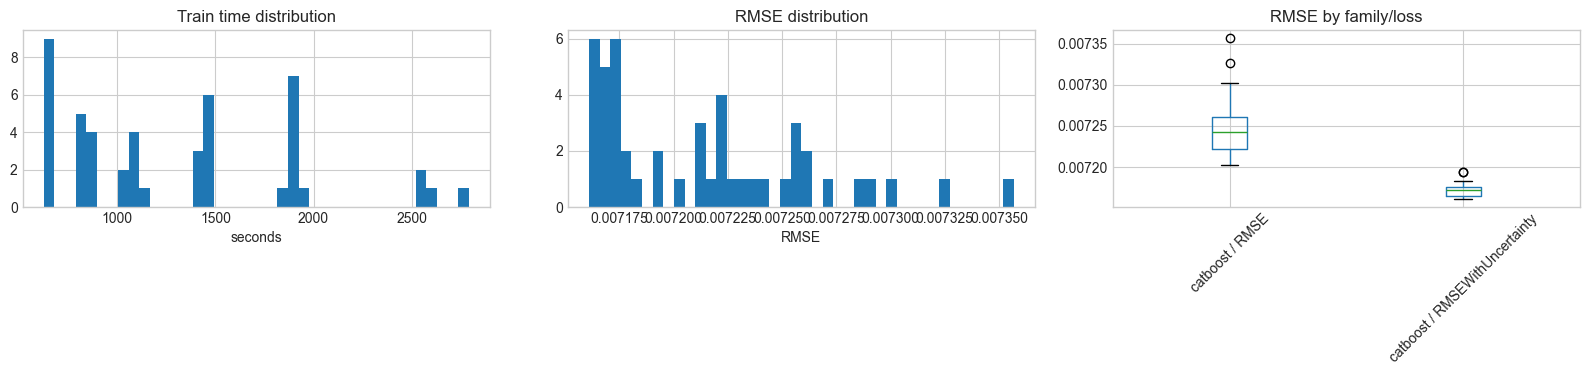

In [5]:
plot_metric_distributions(results)

## 2. Top Models

Compare top lists across different objectives. If the same configurations keep appearing, the signal is stable. If each objective has different winners, Stage 2 should keep separate queues per loss/objective.

In [6]:
tops = top_tables(results, n=TOP_N)
for name, table in tops.items():
    print(f"\n{name}")
    display(table)


Top RMSE


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
26,catboost_uncertainty_002_d4_lr0.03_l210,catboost,RMSEWithUncertainty,0.007161,0.003815,0.516048,0.847283,1443.939761,0.933051,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
25,catboost_uncertainty_001_d4_lr0.03_l23,catboost,RMSEWithUncertainty,0.007162,0.003817,0.515330,0.786413,1442.595689,0.933692,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
29,catboost_uncertainty_005_d4_lr0.05_l210,catboost,RMSEWithUncertainty,0.007163,0.003817,0.516898,0.844022,1477.458530,0.941477,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05}"
27,catboost_uncertainty_003_d4_lr0.03_l230,catboost,RMSEWithUncertainty,0.007163,0.003815,0.514934,0.760870,1456.534762,0.932742,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
34,catboost_uncertainty_010_d6_lr0.03_l23,catboost,RMSEWithUncertainty,0.007163,0.003817,0.517406,0.854348,1865.183968,3.051340,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
35,catboost_uncertainty_011_d6_lr0.03_l210,catboost,RMSEWithUncertainty,0.007164,0.003816,0.518313,0.893478,1909.798120,2.999053,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
30,catboost_uncertainty_006_d4_lr0.05_l230,catboost,RMSEWithUncertainty,0.007166,0.003816,0.516364,0.772283,1414.700201,0.940884,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
28,catboost_uncertainty_004_d4_lr0.05_l23,catboost,RMSEWithUncertainty,0.007166,0.003817,0.516963,0.779348,1446.992311,0.941712,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.05}"
32,catboost_uncertainty_008_d4_lr0.1_l210,catboost,RMSEWithUncertainty,0.007167,0.003820,0.515907,0.703261,1426.856129,0.949409,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.1}"
36,catboost_uncertainty_012_d6_lr0.03_l230,catboost,RMSEWithUncertainty,0.007168,0.003815,0.518447,0.863587,1902.160518,2.989563,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"



Top MAE


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
26,catboost_uncertainty_002_d4_lr0.03_l210,catboost,RMSEWithUncertainty,0.007161,0.003815,0.516048,0.847283,1443.939761,0.933051,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
27,catboost_uncertainty_003_d4_lr0.03_l230,catboost,RMSEWithUncertainty,0.007163,0.003815,0.514934,0.760870,1456.534762,0.932742,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
36,catboost_uncertainty_012_d6_lr0.03_l230,catboost,RMSEWithUncertainty,0.007168,0.003815,0.518447,0.863587,1902.160518,2.989563,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
35,catboost_uncertainty_011_d6_lr0.03_l210,catboost,RMSEWithUncertainty,0.007164,0.003816,0.518313,0.893478,1909.798120,2.999053,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
30,catboost_uncertainty_006_d4_lr0.05_l230,catboost,RMSEWithUncertainty,0.007166,0.003816,0.516364,0.772283,1414.700201,0.940884,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
29,catboost_uncertainty_005_d4_lr0.05_l210,catboost,RMSEWithUncertainty,0.007163,0.003817,0.516898,0.844022,1477.458530,0.941477,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05}"
25,catboost_uncertainty_001_d4_lr0.03_l23,catboost,RMSEWithUncertainty,0.007162,0.003817,0.515330,0.786413,1442.595689,0.933692,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
28,catboost_uncertainty_004_d4_lr0.05_l23,catboost,RMSEWithUncertainty,0.007166,0.003817,0.516963,0.779348,1446.992311,0.941712,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.05}"
34,catboost_uncertainty_010_d6_lr0.03_l23,catboost,RMSEWithUncertainty,0.007163,0.003817,0.517406,0.854348,1865.183968,3.051340,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
45,catboost_uncertainty_021_d8_lr0.03_l230,catboost,RMSEWithUncertainty,0.007173,0.003819,0.518095,0.776630,2790.941042,9.446704,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"



Top Direction Accuracy


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
36,catboost_uncertainty_012_d6_lr0.03_l230,catboost,RMSEWithUncertainty,0.007168,0.003815,0.518447,0.863587,1902.160518,2.989563,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
35,catboost_uncertainty_011_d6_lr0.03_l210,catboost,RMSEWithUncertainty,0.007164,0.003816,0.518313,0.893478,1909.798120,2.999053,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
44,catboost_uncertainty_020_d8_lr0.03_l210,catboost,RMSEWithUncertainty,0.007175,0.003821,0.518146,0.708696,2522.978795,9.472020,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
45,catboost_uncertainty_021_d8_lr0.03_l230,catboost,RMSEWithUncertainty,0.007173,0.003819,0.518095,0.776630,2790.941042,9.446704,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
39,catboost_uncertainty_015_d6_lr0.05_l230,catboost,RMSEWithUncertainty,0.007178,0.003820,0.517899,0.695109,1887.787435,3.038583,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
38,catboost_uncertainty_014_d6_lr0.05_l210,catboost,RMSEWithUncertainty,0.007183,0.003820,0.517856,0.661413,1902.652823,3.046356,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05}"
19,catboost_rmse_020_d8_lr0.03_l210,catboost,RMSE,0.007222,0.003841,0.517787,0.521739,1059.226838,6.056207,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
43,catboost_uncertainty_019_d8_lr0.03_l23,catboost,RMSEWithUncertainty,0.007174,0.003820,0.517584,0.743478,2603.958508,9.707394,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
34,catboost_uncertainty_010_d6_lr0.03_l23,catboost,RMSEWithUncertainty,0.007163,0.003817,0.517406,0.854348,1865.183968,3.051340,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
18,catboost_rmse_019_d8_lr0.03_l23,catboost,RMSE,0.007233,0.003842,0.516970,0.465217,1083.251449,6.166880,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"



Top Composite Score


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
35,catboost_uncertainty_011_d6_lr0.03_l210,catboost,RMSEWithUncertainty,0.007164,0.003816,0.518313,0.893478,1909.798120,2.999053,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
36,catboost_uncertainty_012_d6_lr0.03_l230,catboost,RMSEWithUncertainty,0.007168,0.003815,0.518447,0.863587,1902.160518,2.989563,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
34,catboost_uncertainty_010_d6_lr0.03_l23,catboost,RMSEWithUncertainty,0.007163,0.003817,0.517406,0.854348,1865.183968,3.051340,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
26,catboost_uncertainty_002_d4_lr0.03_l210,catboost,RMSEWithUncertainty,0.007161,0.003815,0.516048,0.847283,1443.939761,0.933051,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
29,catboost_uncertainty_005_d4_lr0.05_l210,catboost,RMSEWithUncertainty,0.007163,0.003817,0.516898,0.844022,1477.458530,0.941477,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05}"
25,catboost_uncertainty_001_d4_lr0.03_l23,catboost,RMSEWithUncertainty,0.007162,0.003817,0.515330,0.786413,1442.595689,0.933692,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
28,catboost_uncertainty_004_d4_lr0.05_l23,catboost,RMSEWithUncertainty,0.007166,0.003817,0.516963,0.779348,1446.992311,0.941712,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.05}"
45,catboost_uncertainty_021_d8_lr0.03_l230,catboost,RMSEWithUncertainty,0.007173,0.003819,0.518095,0.776630,2790.941042,9.446704,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
30,catboost_uncertainty_006_d4_lr0.05_l230,catboost,RMSEWithUncertainty,0.007166,0.003816,0.516364,0.772283,1414.700201,0.940884,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
27,catboost_uncertainty_003_d4_lr0.03_l230,catboost,RMSEWithUncertainty,0.007163,0.003815,0.514934,0.760870,1456.534762,0.932742,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"


In [7]:
top_membership = []
for name, table in tops.items():
    for job_id in table["job_id"].tolist():
        top_membership.append({"leaderboard": name, "job_id": job_id})
top_membership = pd.DataFrame(top_membership)
stability_of_leaders = (
    top_membership.groupby("job_id")
    .agg(leaderboards=("leaderboard", lambda value: ", ".join(sorted(value))), hits=("leaderboard", "count"))
    .reset_index()
    .sort_values(["hits", "job_id"], ascending=[False, True])
)
stability_of_leaders.head(30)

,job_id,leaderboards,hits
9,catboost_uncertainty_010_d6_lr0.03_l23,"Top Composite Score, Top Direction Accuracy, Top MAE, Top RMSE",4
10,catboost_uncertainty_011_d6_lr0.03_l210,"Top Composite Score, Top Direction Accuracy, Top MAE, Top RMSE",4
11,catboost_uncertainty_012_d6_lr0.03_l230,"Top Composite Score, Top Direction Accuracy, Top MAE, Top RMSE",4
2,catboost_uncertainty_001_d4_lr0.03_l23,"Top Composite Score, Top MAE, Top RMSE",3
3,catboost_uncertainty_002_d4_lr0.03_l210,"Top Composite Score, Top MAE, Top RMSE",3
4,catboost_uncertainty_003_d4_lr0.03_l230,"Top Composite Score, Top MAE, Top RMSE",3
5,catboost_uncertainty_004_d4_lr0.05_l23,"Top Composite Score, Top MAE, Top RMSE",3
6,catboost_uncertainty_005_d4_lr0.05_l210,"Top Composite Score, Top MAE, Top RMSE",3
7,catboost_uncertainty_006_d4_lr0.05_l230,"Top Composite Score, Top MAE, Top RMSE",3
16,catboost_uncertainty_021_d8_lr0.03_l230,"Top Composite Score, Top Direction Accuracy, Top MAE",3


## 3. Single-Parameter Analysis

For each hyperparameter, inspect the full distribution and the share of Top-10 models. The important question is not only which value has the best single run, but which value repeatedly produces good runs.

In [8]:
analysis_scope = results.loc[results["model_family"].eq(PRIMARY_MODEL_FAMILY)].copy()
if PRIMARY_LOSS_FUNCTION is not None:
    analysis_scope = analysis_scope.loc[analysis_scope["loss_function"].eq(PRIMARY_LOSS_FUNCTION)].copy()

param_cols = parameter_columns(analysis_scope)
print(f"scope rows={len(analysis_scope)}, params={param_cols}")

scope rows=47, params=['param_bootstrap_type', 'param_depth', 'param_iterations', 'param_l2_leaf_reg', 'param_learning_rate']



param_bootstrap_type


,param_bootstrap_type,count,mean,median,std,best,worst,top10_count
0,Bayesian,47,0.007214,0.00721,0.000049,0.007161,0.007357,10



param_depth


,param_depth,count,mean,median,std,best,worst,top10_count
0,4,18,0.007199,0.007190,0.000037,0.007161,0.007261,7
1,6,18,0.007218,0.007204,0.000051,0.007163,0.007327,3
2,8,11,0.007232,0.007222,0.000059,0.007173,0.007357,0



param_iterations


,param_iterations,count,mean,median,std,best,worst,top10_count
0,3000,47,0.007214,0.00721,0.000049,0.007161,0.007357,10



param_l2_leaf_reg


,param_l2_leaf_reg,count,mean,median,std,best,worst,top10_count
2,30,15,0.007208,0.007203,0.000043,0.007163,0.007302,3
0,3,17,0.007219,0.007210,0.000056,0.007162,0.007357,3
1,10,15,0.007214,0.007211,0.000048,0.007161,0.007327,4



param_learning_rate


,param_learning_rate,count,mean,median,std,best,worst,top10_count
0,0.03,18,0.007192,0.007189,0.000027,0.007161,0.007233,6
1,0.05,16,0.007216,0.007225,0.000043,0.007163,0.007287,3
2,0.10,13,0.007240,0.007253,0.000065,0.007167,0.007357,1


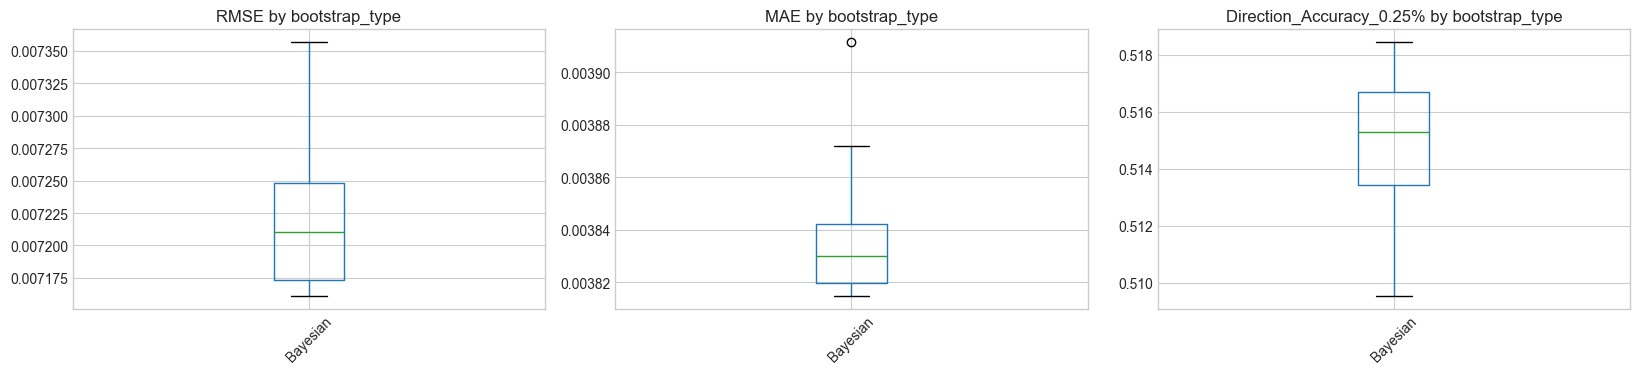

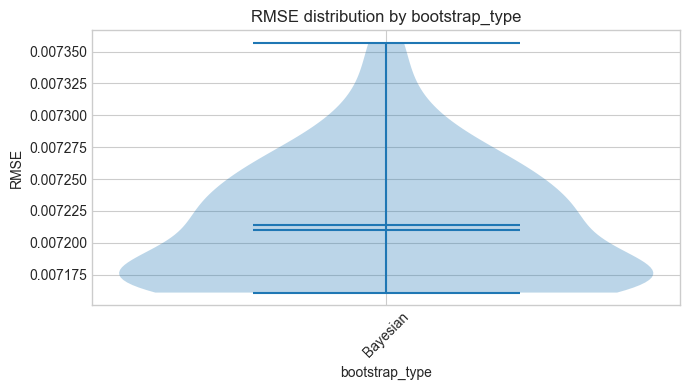

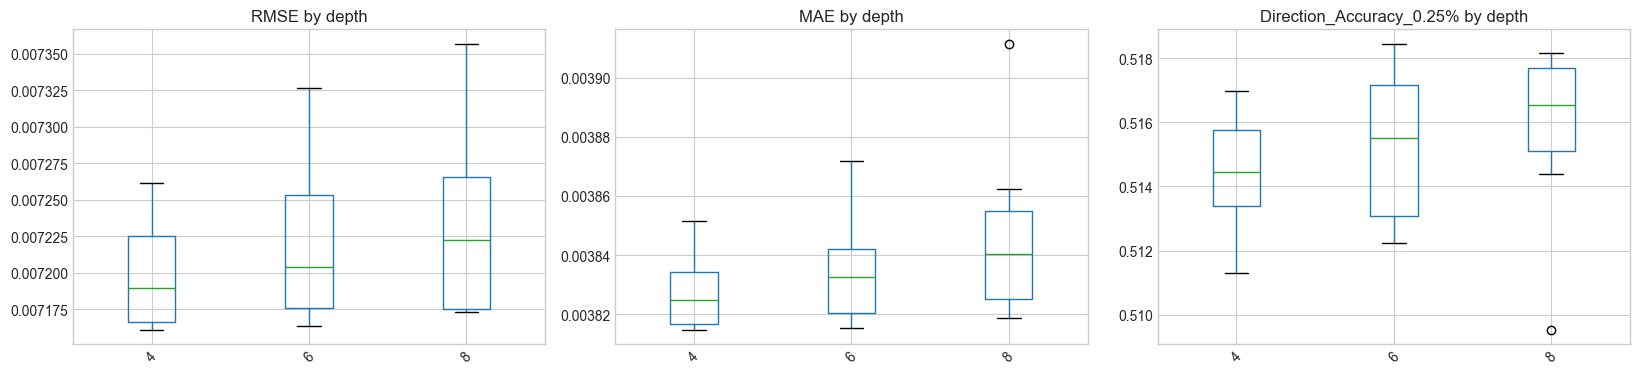

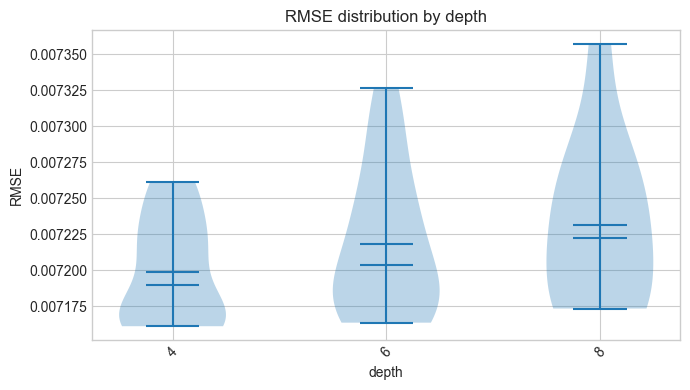

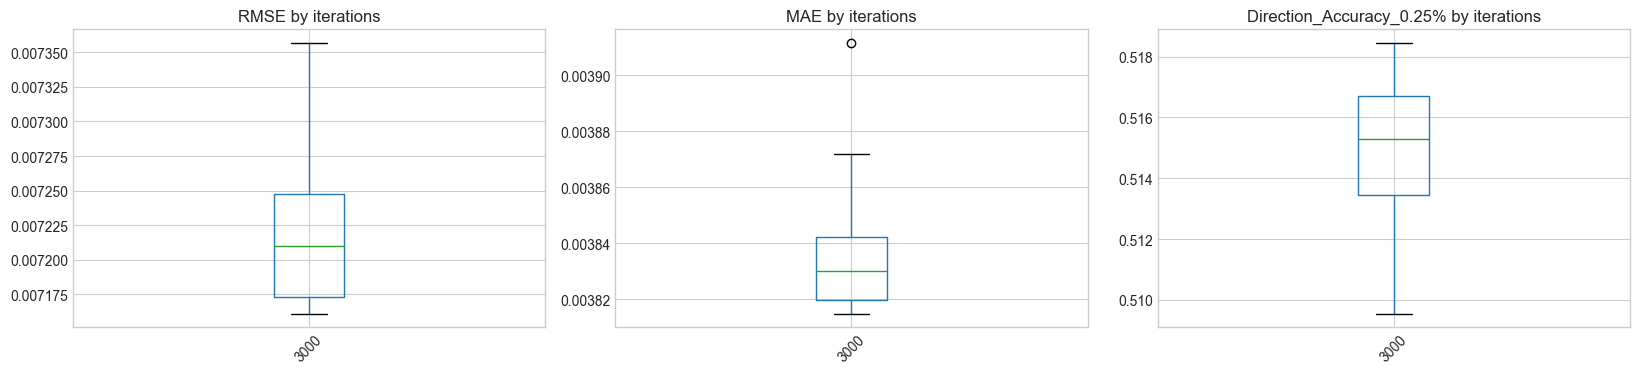

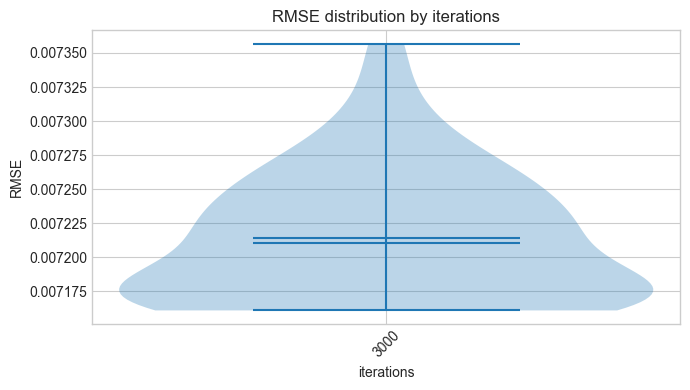

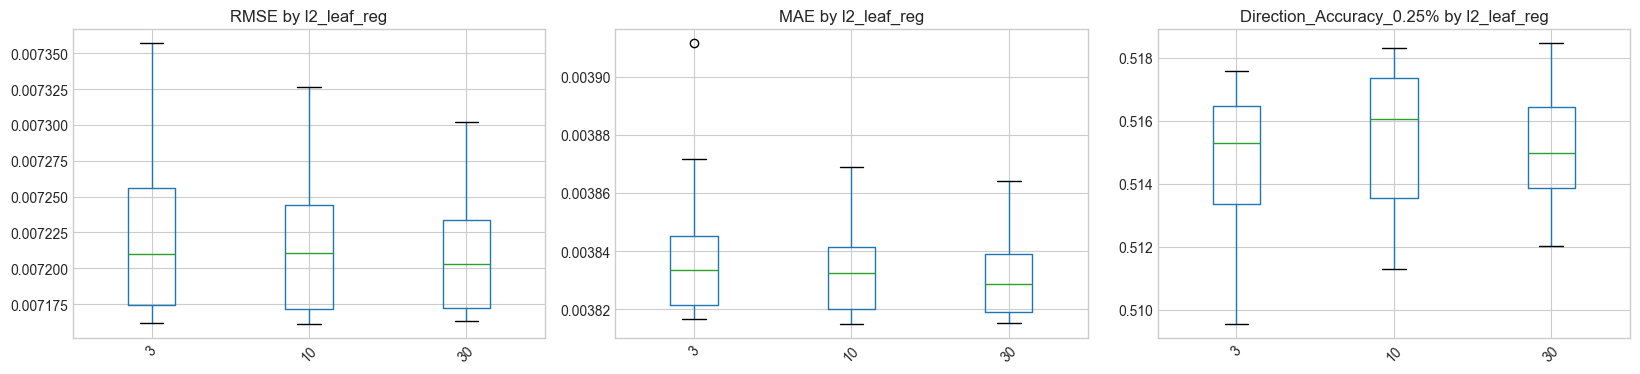

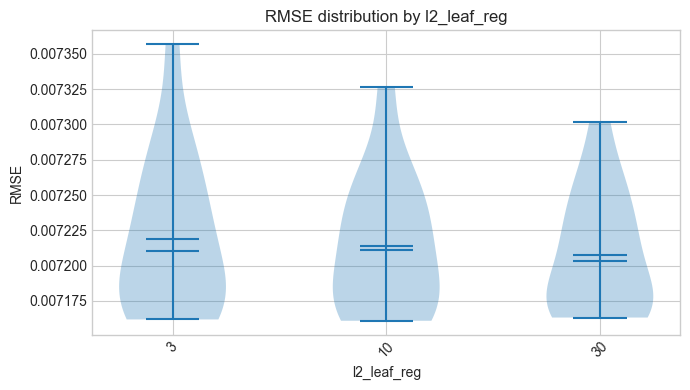

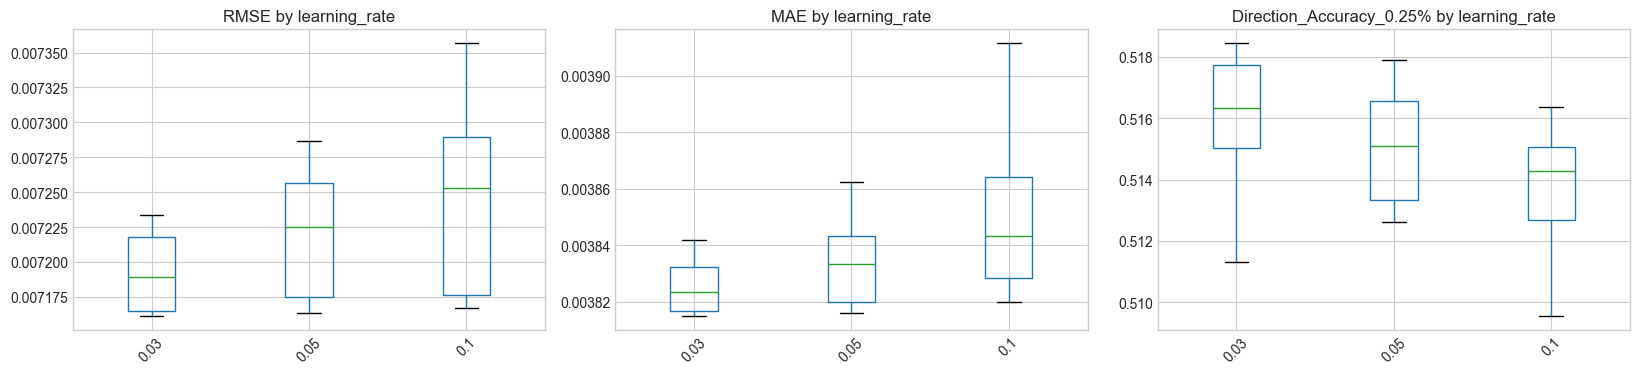

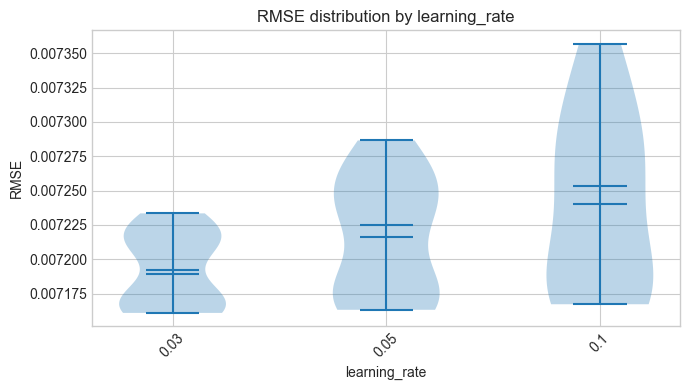

In [9]:
for param in param_cols:
    print(f"\n{param}")
    display(parameter_summary(analysis_scope, param, metric=PRIMARY_METRIC, top_n=TOP_N))
    plot_param_distribution(analysis_scope, param)
    plot_violin_distribution(analysis_scope, param, metric=PRIMARY_METRIC)

## 4. Pairwise Dependencies

Heatmaps reveal interactions that single-parameter summaries hide: for example, a deep tree may be useful only with a small learning rate.

param_learning_rate,0.03,0.05,0.10
param_depth,,,
4,0.007183,0.007195,0.007215
6,0.007190,0.007213,0.007242
8,0.007197,0.007266,0.007357


param_l2_leaf_reg,3,10,30
param_depth,,,
4,0.007193,0.007189,0.007187
6,0.007209,0.007208,0.007195
8,0.007233,0.007222,0.007219


param_l2_leaf_reg,3,10,30
param_learning_rate,,,
0.03,0.007192,0.007193,0.007188
0.05,0.007200,0.007235,0.007225
0.10,0.007258,0.007224,0.007217


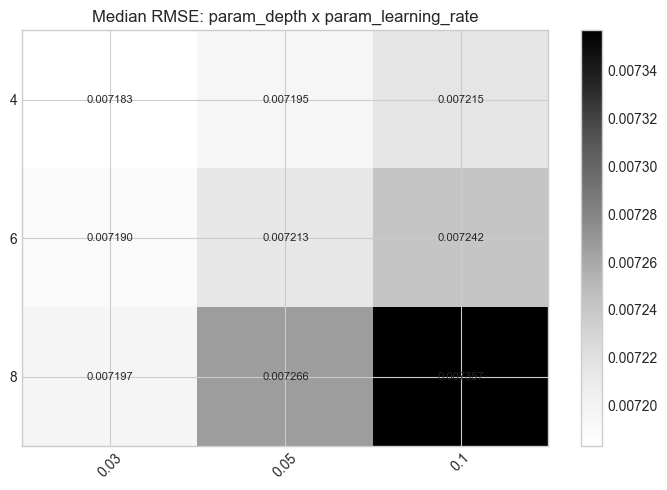

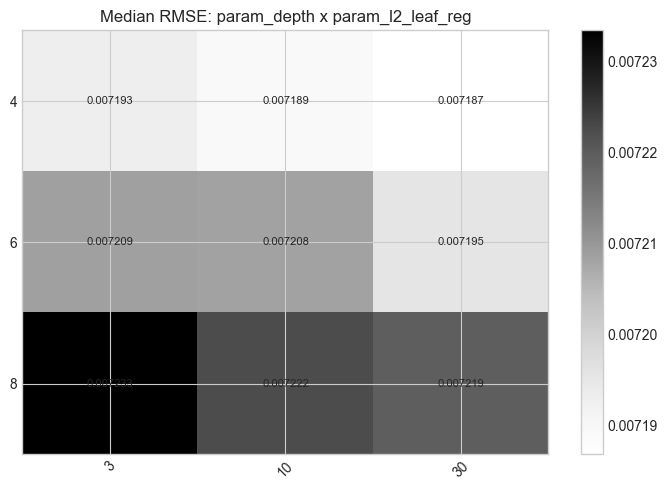

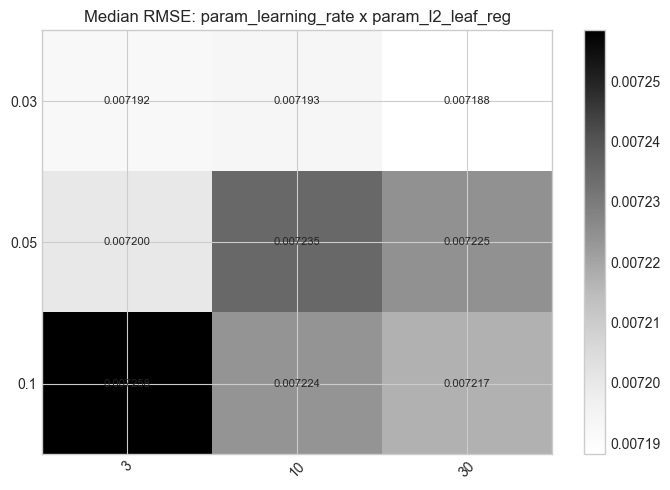

In [10]:
pairs = [
    ("param_depth", "param_learning_rate"),
    ("param_depth", "param_l2_leaf_reg"),
    ("param_learning_rate", "param_l2_leaf_reg"),
    ("param_num_leaves", "param_learning_rate"),
    ("param_max_depth", "param_num_leaves"),
]

for row_param, col_param in pairs:
    if row_param in analysis_scope.columns and col_param in analysis_scope.columns:
        pivot = pair_pivot(analysis_scope, row_param, col_param, metric=PRIMARY_METRIC, aggfunc="median")
        display(pivot)
        plot_heatmap(pivot, title=f"Median {PRIMARY_METRIC}: {row_param} x {col_param}")

## 5. Hyperparameter Importance

A small RandomForest surrogate estimates which hyperparameters explain variation in the target metric. This is not the final model; it is an analyzer of the grid-search results.

In [11]:
hp_importance, hp_model, hp_matrix = hyperparameter_importance(
    analysis_scope,
    metric=PRIMARY_METRIC,
    param_cols=param_cols,
)
hp_importance

,parameter,rf_importance,permutation_importance_mean,permutation_importance_std
2,param_learning_rate,0.481776,0.485207,0.151385
0,param_depth,0.340301,0.292846,0.131973
1,param_l2_leaf_reg,0.177924,0.012349,0.016604


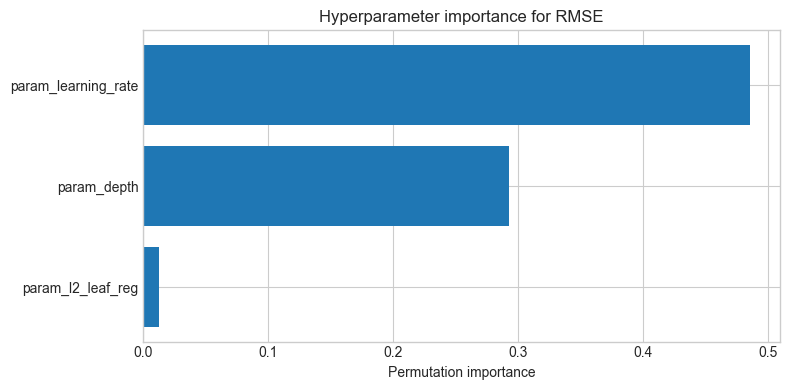

In [12]:
if not hp_importance.empty:
    plot = hp_importance.sort_values("permutation_importance_mean")
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(plot["parameter"], plot["permutation_importance_mean"])
    ax.set_title(f"Hyperparameter importance for {PRIMARY_METRIC}")
    ax.set_xlabel("Permutation importance")
    plt.tight_layout()

## 6. Partial Dependence

Partial dependence approximates the metric trend after averaging over other hyperparameters.

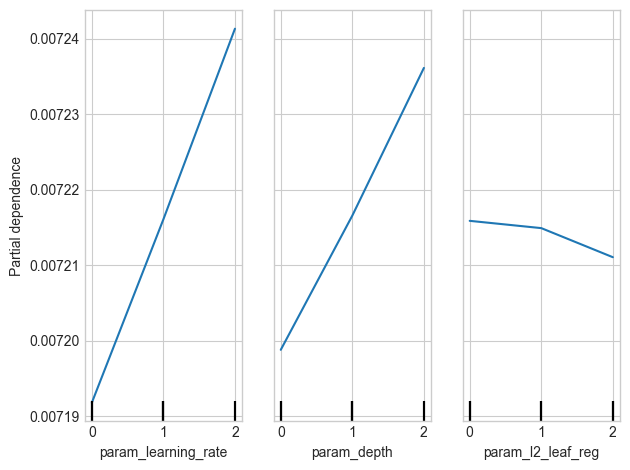

In [13]:
pd_params = hp_importance["parameter"].head(3).tolist() if not hp_importance.empty else []
plot_partial_dependence(hp_model, hp_matrix, pd_params)

## 7. Correlations With Cost And Quality

This section is useful for ruling out expensive regions that do not buy better quality.

In [14]:
parameter_correlations(analysis_scope)

,parameter,target,spearman,pearson
4,param_depth,model_size_mb,0.935538,0.900196
11,param_learning_rate,MAE,0.456134,0.464450
12,param_learning_rate,Direction_Accuracy_0.25%,-0.405280,-0.392966
3,param_depth,train_time,0.389344,0.387100
10,param_learning_rate,RMSE,0.381403,0.387217
1,param_depth,MAE,0.344415,0.359026
2,param_depth,Direction_Accuracy_0.25%,0.330859,0.285665
0,param_depth,RMSE,0.287249,0.266759
6,param_l2_leaf_reg,MAE,-0.161970,-0.165034
9,param_l2_leaf_reg,model_size_mb,-0.143565,-0.089018


## 8. Pareto Frontier

The frontier keeps only models where no other model is both faster and better. Anything dominated is a bad Stage 2 seed unless it wins on another objective.

,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,train_time,model_size_mb,params
26,catboost_uncertainty_002_d4_lr0.03_l210,catboost,RMSEWithUncertainty,0.007161,0.003815,0.516048,1443.939761,0.933051,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
25,catboost_uncertainty_001_d4_lr0.03_l23,catboost,RMSEWithUncertainty,0.007162,0.003817,0.515330,1442.595689,0.933692,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
30,catboost_uncertainty_006_d4_lr0.05_l230,catboost,RMSEWithUncertainty,0.007166,0.003816,0.516364,1414.700201,0.940884,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
2,catboost_rmse_003_d4_lr0.03_l230,catboost,RMSE,0.007203,0.003826,0.512031,624.755811,0.582537,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"


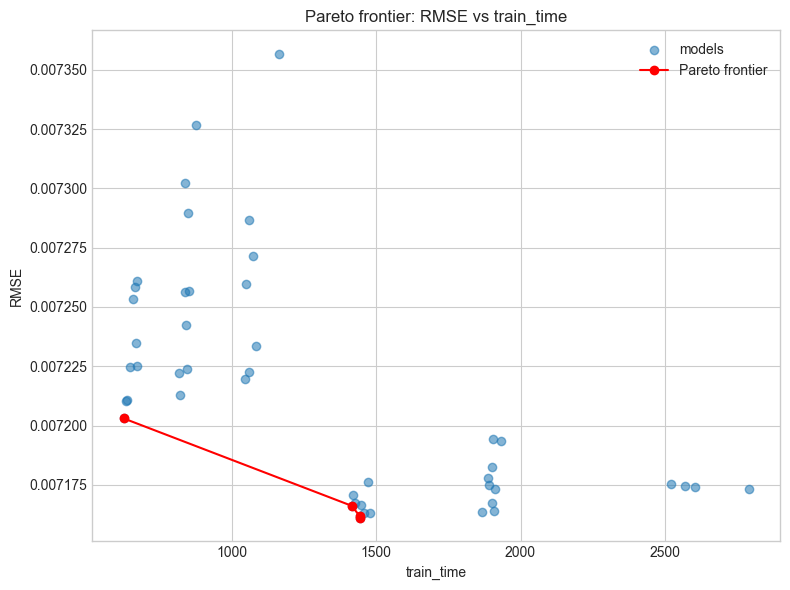

In [15]:
frontier = pareto_frontier(analysis_scope, quality_metric=PRIMARY_METRIC, cost_metric="train_time")
pareto_columns = ["job_id", "model_family", "loss_function", PRIMARY_METRIC, "MAE", "Direction_Accuracy_0.25%", "train_time", "model_size_mb", "params"]
pareto_columns = [column for column in pareto_columns if column in frontier.columns]
display(frontier.loc[:, pareto_columns])
plot_pareto(analysis_scope, frontier, quality_metric=PRIMARY_METRIC, cost_metric="train_time")

## 9. Stability Analysis

If Top-20 differs from Top-1 by a tiny amount, Stage 2 should optimize for simpler/faster regions instead of chasing noise.

In [16]:
stability_table(analysis_scope, metric=PRIMARY_METRIC, sizes=(5, 10, 20, 30))

,top_n,rows,best,worst,spread,spread_vs_best_pct,std
0,5,5,0.007161,0.007163,0.000002,0.034406,0.000001
1,10,10,0.007161,0.007168,0.000007,0.092163,0.000002
2,20,20,0.007161,0.007183,0.000022,0.302861,0.000006
3,30,30,0.007161,0.007224,0.000063,0.876154,0.000021


## 10. What If Grid Search Stopped Earlier?

This curve shows how quickly the best result saturated as models completed.

,models_seen,job_id,RMSE,best_so_far
2,1,catboost_rmse_003_d4_lr0.03_l230,0.007203,0.007203
0,2,catboost_rmse_001_d4_lr0.03_l23,0.007210,0.007203
1,3,catboost_rmse_002_d4_lr0.03_l210,0.007211,0.007203
3,4,catboost_rmse_004_d4_lr0.05_l23,0.007225,0.007203
4,5,catboost_rmse_005_d4_lr0.05_l210,0.007235,0.007203
25,6,catboost_uncertainty_001_d4_lr0.03_l23,0.007162,0.007162
26,7,catboost_uncertainty_002_d4_lr0.03_l210,0.007161,0.007161
27,8,catboost_uncertainty_003_d4_lr0.03_l230,0.007163,0.007161
5,9,catboost_rmse_006_d4_lr0.05_l230,0.007225,0.007161
28,10,catboost_uncertainty_004_d4_lr0.05_l23,0.007166,0.007161


,models_seen,job_id,RMSE,best_so_far
37,28,catboost_uncertainty_013_d6_lr0.05_l23,0.007175,0.007161
15,29,catboost_rmse_016_d6_lr0.1_l23,0.007290,0.007161
16,30,catboost_rmse_017_d6_lr0.1_l210,0.007327,0.007161
38,31,catboost_uncertainty_014_d6_lr0.05_l210,0.007183,0.007161
39,32,catboost_uncertainty_015_d6_lr0.05_l230,0.007178,0.007161
17,33,catboost_rmse_018_d6_lr0.1_l230,0.007302,0.007161
40,34,catboost_uncertainty_016_d6_lr0.1_l23,0.007194,0.007161
18,35,catboost_rmse_019_d8_lr0.03_l23,0.007233,0.007161
41,36,catboost_uncertainty_017_d6_lr0.1_l210,0.007194,0.007161
19,37,catboost_rmse_020_d8_lr0.03_l210,0.007222,0.007161


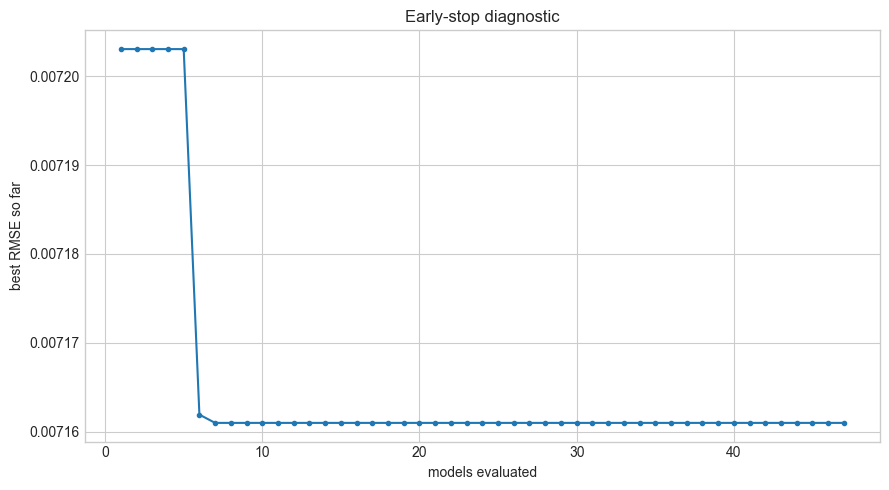

In [17]:
curve = early_stop_curve(analysis_scope, metric=PRIMARY_METRIC)
display(curve.head(20))
display(curve.tail(20))
plot_early_stop(curve, metric=PRIMARY_METRIC)

## 11. Automatic Stage 2 Grid

The grid below is generated from the best Stage 1 region and expanded locally. The notes explain which Stage 1 values are being discarded.

In [18]:
stage2_grid, stage2_notes, stage2_seed_models = suggest_stage2_grid(
    results,
    model_family=PRIMARY_MODEL_FAMILY,
    loss_function=PRIMARY_LOSS_FUNCTION,
    metric=PRIMARY_METRIC,
    top_n=TOP_N,
)

print(format_grid_as_python(stage2_grid, variable_name="GRID_STAGE2"))
print("\nExclusion / retention notes:")
for note in stage2_notes:
    print("-", note)

stage2_seed_columns = ["job_id", "model_family", "loss_function", PRIMARY_METRIC, "MAE", "Direction_Accuracy_0.25%", "train_time", "params"]
stage2_seed_columns = [column for column in stage2_seed_columns if column in stage2_seed_models.columns]
stage2_seed_models.loc[:, stage2_seed_columns]

GRID_STAGE2 = {
    "bootstrap_type": [
        "Bayesian"
    ],
    "depth": [
        3,
        4,
        5,
        6,
        7
    ],
    "iterations": [
        3000
    ],
    "l2_leaf_reg": [
        1.5,
        3.0,
        4.5,
        5.0,
        10.0,
        15.0,
        30.0,
        45.0
    ],
    "learning_rate": [
        0.021,
        0.03,
        0.035,
        0.039,
        0.05,
        0.065,
        0.07,
        0.1,
        0.13
    ],
    "bagging_temperature": [
        0,
        1,
        3
    ],
    "rsm": [
        0.7,
        0.85,
        1.0
    ],
    "random_strength": [
        0,
        1,
        2
    ]
}

Exclusion / retention notes:
- bootstrap_type: keep around ['Bayesian'].
- depth: exclude [8]; top-10 used [4, 6].
- iterations: keep around [3000].
- l2_leaf_reg: keep around [3, 10, 30].
- learning_rate: keep around [0.03, 0.05, 0.1].


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,train_time,params
26,catboost_uncertainty_002_d4_lr0.03_l210,catboost,RMSEWithUncertainty,0.007161,0.003815,0.516048,1443.939761,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
25,catboost_uncertainty_001_d4_lr0.03_l23,catboost,RMSEWithUncertainty,0.007162,0.003817,0.515330,1442.595689,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
29,catboost_uncertainty_005_d4_lr0.05_l210,catboost,RMSEWithUncertainty,0.007163,0.003817,0.516898,1477.458530,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05}"
27,catboost_uncertainty_003_d4_lr0.03_l230,catboost,RMSEWithUncertainty,0.007163,0.003815,0.514934,1456.534762,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
34,catboost_uncertainty_010_d6_lr0.03_l23,catboost,RMSEWithUncertainty,0.007163,0.003817,0.517406,1865.183968,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
35,catboost_uncertainty_011_d6_lr0.03_l210,catboost,RMSEWithUncertainty,0.007164,0.003816,0.518313,1909.798120,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
30,catboost_uncertainty_006_d4_lr0.05_l230,catboost,RMSEWithUncertainty,0.007166,0.003816,0.516364,1414.700201,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
28,catboost_uncertainty_004_d4_lr0.05_l23,catboost,RMSEWithUncertainty,0.007166,0.003817,0.516963,1446.992311,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.05}"
32,catboost_uncertainty_008_d4_lr0.1_l210,catboost,RMSEWithUncertainty,0.007167,0.003820,0.515907,1426.856129,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.1}"
36,catboost_uncertainty_012_d6_lr0.03_l230,catboost,RMSEWithUncertainty,0.007168,0.003815,0.518447,1902.160518,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"


## 12. Feature Importance Check For Top Models

This is not hyperparameter-space analysis, but it is useful for verifying whether the HMM posterior features are actually used by the best models.

In [19]:
def load_feature_importance(row: pd.Series) -> pd.DataFrame:
    key = row.get("feature_importance_key")
    if not isinstance(key, str) or not key:
        return pd.DataFrame()
    frame = read_parquet(s3, BUCKET, key)
    if frame.empty:
        return frame
    frame = frame.copy()
    frame["job_id"] = row["job_id"]
    frame["loss_function"] = row["loss_function"]
    frame["RMSE"] = row["RMSE"]
    return frame


importance_source = results.sort_values(["RMSE", "MAE", "job_id"]).head(TOP_N)
feature_importance = pd.concat(
    [load_feature_importance(row) for _, row in importance_source.iterrows()],
    ignore_index=True,
) if len(importance_source) else pd.DataFrame()

if feature_importance.empty:
    print("No feature importance data loaded yet.")
else:
    feature_importance["importance_abs"] = feature_importance["importance"].abs()
    aggregate_importance = (
        feature_importance.groupby("feature", as_index=False)
        .agg(mean_abs_importance=("importance_abs", "mean"), jobs=("job_id", "nunique"))
        .sort_values("mean_abs_importance", ascending=False)
    )
    display(aggregate_importance.head(30))
    display(aggregate_importance.loc[aggregate_importance["feature"].str.startswith("price_hmm_n4_")])

,feature,mean_abs_importance,jobs
56,price_hmm_n4_prob_state_2,22.626000,10
57,price_hmm_n4_prob_state_3,17.134157,10
31,ada_realized_volatility_60m,16.044006,10
36,ada_return_std_60m,11.370860,10
30,ada_realized_volatility_20m,3.571799,10
58,time_of_day_cos,1.980245,10
59,time_of_day_sin,1.894290,10
55,price_hmm_n4_prob_state_1,1.605701,10
38,ada_trades_per_minute_5m,1.493088,10
43,ada_volume_sum_30m,1.359491,10


,feature,mean_abs_importance,jobs
56,price_hmm_n4_prob_state_2,22.626000,10
57,price_hmm_n4_prob_state_3,17.134157,10
55,price_hmm_n4_prob_state_1,1.605701,10
54,price_hmm_n4_prob_state_0,0.725040,10
